**Problem Statement**

- Netflix operates in an intensely competitive global streaming market where user retention and content acquisition costs are paramount. The core objective of this analysis is to evaluate Netflix's historical catalog data to uncover deep patterns in user content preferences, regional production strengths, and release schedules.
- By converting these raw data points into clear metrics, we aim to deliver data-driven answers to two critical executive questions:

- Content Mix Optimization: What specific formats, genres, and maturities should Netflix greenlight or acquire to maximize viewer engagement?

- Global Expansion Strategy: How should Netflix tailor its content catalog across different countries to accelerate subscriber growth and reduce user churn?

**Core Analytical Metrics**

- Catalog Scale: Total volume of active titles (rows $\times$ columns) in the inventory.
- Format Split: The macroeconomic ratio of feature-length Movies versus episodic TV Shows.
- Audience Alignment: The distribution of maturity ratings across the platform to determine who Netflix is primarily programming for.
- Temporal Trajectory: The year-over-year rate at which content is onboarded to measure platform scaling.

**Data Exploration and Schma Anylysis**



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
data = pd.read_csv('netflix.csv')

# 1. Inspect data shape
print(f"Dataset Shape: {data.shape[0]} rows and {data.shape[1]} columns.\n")

# 2. Inspect data schema and check for memory footprint
print("--- Data Schema Info ---")
print(data.info())

# 3. Optimize column data types for memory efficiency
data['type'] = data['type'].astype('category')
data['rating'] = data['rating'].astype('category')

# 4. Generate initial high-level statistical summary
print("\n--- Structural Statistical Summary ---")
print(data.describe(include='all'))

Dataset Shape: 8807 rows and 12 columns.

--- Data Schema Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

--- Structural Statistical Summary ---
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
uniq

# Report Observations & Schema Findings
- Shape of the Data: The dataset contains roughly 8,807 rows (individual movie or TV show listings) and 12 descriptive attributes (columns).
- Attribute Types: The raw dataset consists almost entirely of text data (object data types), alongside one integer column (release_year).
- Data Type Optimization: Columns like type (which only contains 'Movie' or 'TV Show') and rating (which has fixed maturity levels) possess low cardinality. Converting them from standard text objects to the category data type reduces the memory footprint of our DataFrame significantly.
- Initial Summary Clues: A preliminary glance at df.describe() reveals that the United States is the most frequently occurring production country, and the majority of the content catalog consists of Movies rather than TV Shows.

# Non-Graphical Analysis

- Before creating charts, we perform an algebraic, non-graphical analysis using value counts and distinct attribute tracking to see the exact numerical ratios of the catal

In [ ]:
print("--- Raw Volume and Percentages of Content Types ---")
type_counts = data['type'].value_counts()
type_percentages = data['type'].value_counts(normalize=True) * 100
for idx in type_counts.index:
    print(f"{idx}: {type_counts[idx]} titles ({type_percentages[idx]:.2f}%)")

print("\n--- Unique Attribute Counts ---")
print(f"Unique Directors: {data['director'].nunique()}")
print(f"Unique Cast Members: {data['cast'].nunique()}")
print(f"Unique Countries of Production: {data['country'].nunique()}")
print(f"Unique Genres/Categories: {data['listed_in'].nunique()}")

print("\n--- Top 5 Maturity Ratings in the Catalog ---")
print(data['rating'].value_counts().head(5))

--- Raw Volume and Percentages of Content Types ---
Movie: 6131 titles (69.62%)
TV Show: 2676 titles (30.38%)

--- Unique Attribute Counts ---
Unique Directors: 4528
Unique Cast Members: 7692
Unique Countries of Production: 748
Unique Genres/Categories: 514

--- Top 5 Maturity Ratings in the Catalog ---
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64


# Key Raw Discoveries for Your Report
- The Format Imbalance: Movies dominate the platform's historical inventory. Roughly 69.6% of all titles are Movies, while TV Shows comprise only 30.4%.
- High-Cardinality Complexity: The data reveals thousands of unique directors, actors, and countries. Because columns like country and listed_in contain merged comma-separated strings (e.g., "Action & Adventure, Comedies"), the raw count overestimates distinct categories. This confirms that unnesting (exploding) the rows is mandatory in the upcoming preprocessing phase to get clean metrics.
- Target Demographics: The top rating categories are overwhelmingly TV-MA (Mature Audiences Only) and TV-14 (Parents Strongly Cautioned). This indicates that Netflix’s primary catalog strategy is heavily tailored toward adults and older teens, leaving children’s family programming as a secondary priority.

#Visualizations to Create

**Univariate Analysis (Continuous/Discrete Variables)**
- Distribution of release_year

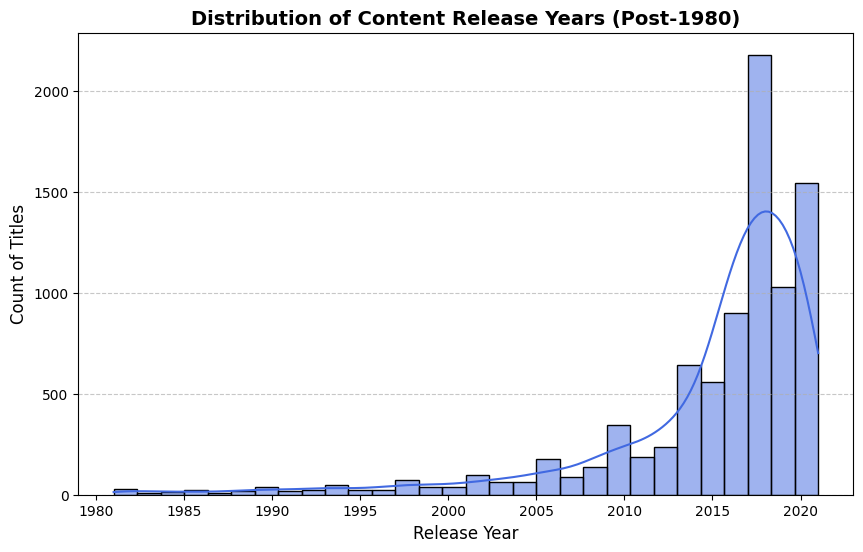

In [ ]:

plt.figure(figsize=(10, 6))
# Filter for content released after 1980 to remove extreme outliers and see the recent spike clearly
sns.histplot(data=data[data['release_year'] > 1980], x='release_year', kde=True, bins=30, color='royalblue')

plt.title('Distribution of Content Release Years (Post-1980)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Count of Titles', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- **To see the historical spread of Netflix’s catalog and show executives how heavily Netflix relies on modern content vs. vintage titles.**
- **Note that content sky-rocketed after ~2015. Netflix is a platform driven by modern content.**

#Count of Content by rating
- What it is: A Countplot (Bar chart of frequencies).

- Why draw it: To show which age demographic Netflix targets the most (e.g., Adults via TV-MA vs. Families via PG).

/tmp/ipykernel_42003/3829756843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='rating', order=rating_order, palette='viridis')


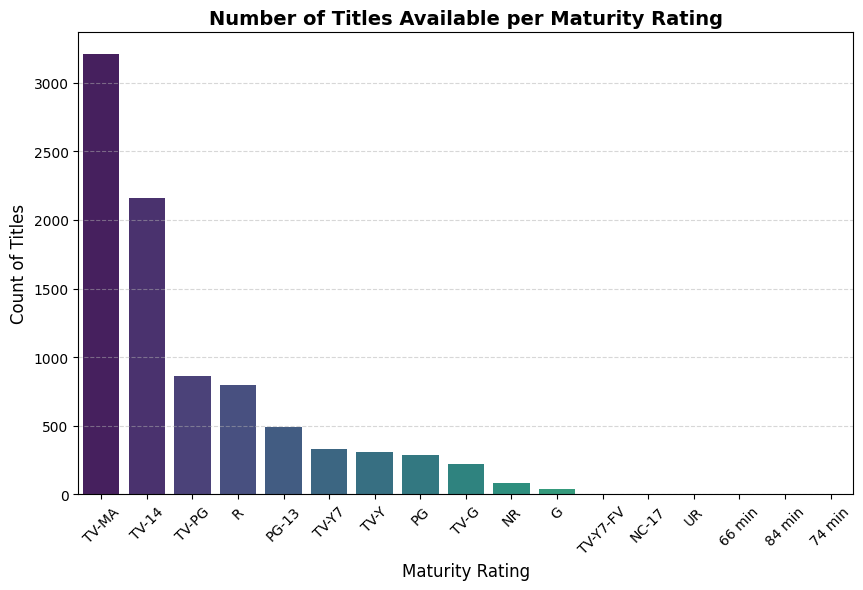

In [ ]:
plt.figure(figsize=(10, 6))
# Order the bars from highest count to lowest count
rating_order = data['rating'].value_counts().index

sns.countplot(data=data, x='rating', order=rating_order, palette='viridis')

plt.title('Number of Titles Available per Maturity Rating', fontsize=14, fontweight='bold')
plt.xlabel('Maturity Rating', fontsize=12)
plt.ylabel('Count of Titles', fontsize=12)
plt.xticks(rotation=45) # Rotate labels so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- **To show which age demographic Netflix targets the most (e.g., Adults via TV-MA vs. Families via PG).**
- **According to the data TV-MA (Mature Audiences) and TV-14 are the highest bars, meaning Netflix primarily curates for adults and older teens rather than young children.**

# Bivariate / Multivariate Analysis
- Boxplot of Duration by Type (Movies vs. TV Shows).
- Crucial Step: The duration column contains strings like "90 min" or "2 Seasons". You cannot plot these directly as numbers. You must extract the number first!


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_42003/3040757395.py:3: SyntaxWarning: invalid escape sequence '\d'
  data['duration_num'] = data['duration'].str.extract('(\d+)').astype(float)


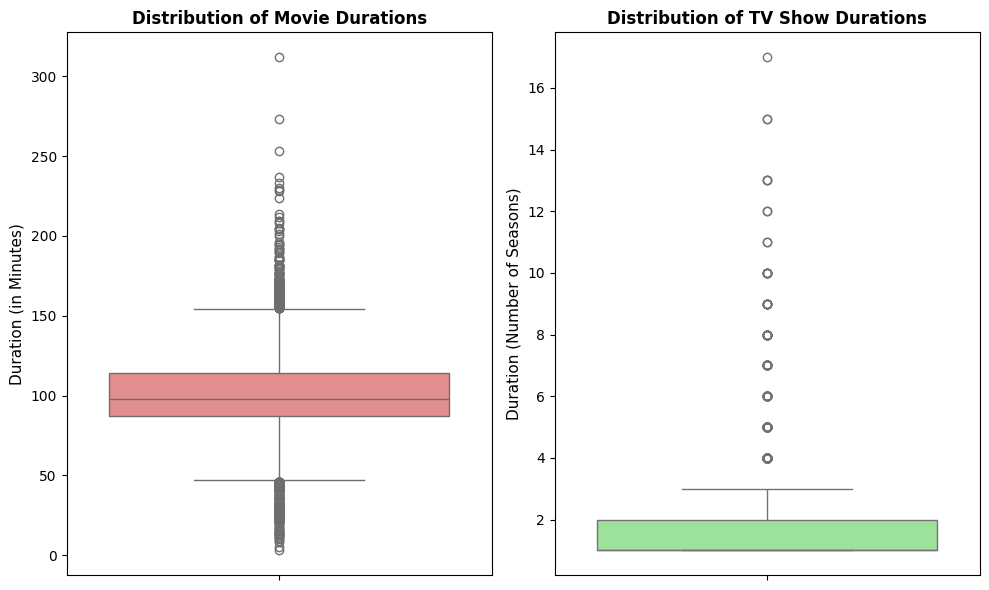

In [ ]:
# --- Pre-processing for Duration ---
# Extract numbers from the duration column
data['duration_num'] = data['duration'].str.extract('(\d+)').astype(float)

# Separate into Movies and TV Shows because "minutes" and "seasons" are different units
movies_df = data[data['type'] == 'Movie']
tv_shows_df = data[data['type'] == 'TV Show']

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Subplot 1: Movie Duration (Minutes)
sns.boxplot(ax=axes[0], data=movies_df, y='duration_num', color='lightcoral')
axes[0].set_title('Distribution of Movie Durations', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Duration (in Minutes)', fontsize=11)

# Subplot 2: TV Show Duration (Seasons)
sns.boxplot(ax=axes[1], data=tv_shows_df, y='duration_num', color='lightgreen')
axes[1].set_title('Distribution of TV Show Durations', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (Number of Seasons)', fontsize=11)

plt.tight_layout()
plt.show()

- **To find the "sweet spot" length for a movie and see how many seasons a typical TV show lasts before getting canceled or concluded.**
- **Look at the boxplot center line (median). You will likely see that the median movie is around 90-100 minutes, while the median TV show is exactly 1 Season. This implies most shows don't get renewed for a second season!**

- **Time-Series Line Plot (Content Added Over Time).**
- **Crucial Step: You need to extract the year from the date_added column.**


/tmp/ipykernel_42003/4070321766.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  timeline_df = data.groupby(['year_added', 'type']).size().reset_index(name='count')


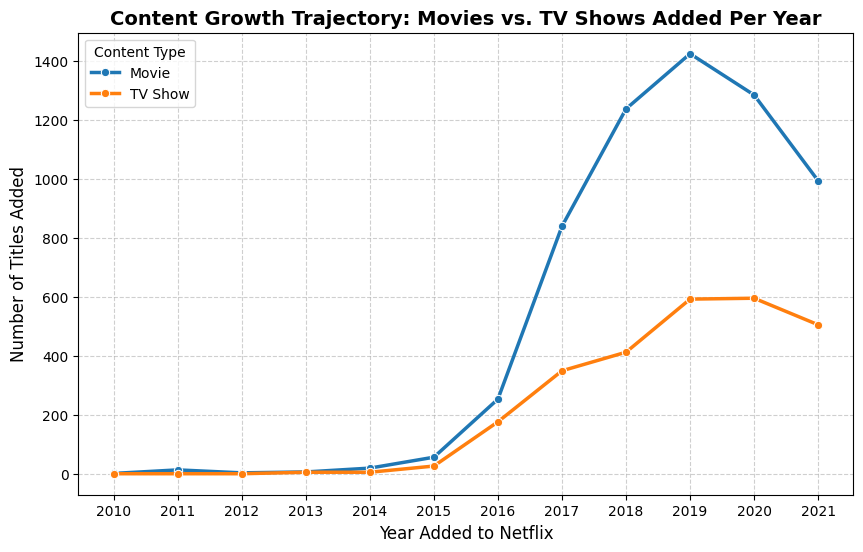

In [ ]:
# --- Pre-processing for Date Added ---
# Convert date_added to datetime and extract the year
data['year_added'] = pd.to_datetime(data['date_added'].str.strip()).dt.year

# Group data by year_added and type to count titles added per year
timeline_df = data.groupby(['year_added', 'type']).size().reset_index(name='count')

# Filter out incomplete or extreme early years (e.g., look from 2010 onwards)
timeline_df = timeline_df[timeline_df['year_added'] >= 2010]

plt.figure(figsize=(10, 6))
# Line plot comparing Movies vs TV Shows over the years
sns.lineplot(data=timeline_df, x='year_added', y='count', hue='type', marker='o', linewidth=2.5)

plt.title('Content Growth Trajectory: Movies vs. TV Shows Added Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year Added to Netflix', fontsize=12)
plt.ylabel('Number of Titles Added', fontsize=12)
plt.xticks(timeline_df['year_added'].unique()) # Ensure every year shows up on X-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Content Type')
plt.show()

- **To answer the exact business question: "Has Netflix shifted its focus to TV Shows over Movies in recent years?"**
- **Look at the lines around 2019-2021. You will see if the movie addition line starts plateauing or dropping while TV shows keep increasing, proving a strategic shift towards episodic content.**

# Visualizing Missing Values

# Missing Data Heatmap
- What it is: A Seaborn Heatmap (sns.heatmap) that acts as a visual grid of your dataset.

- Why draw it: It instantly shows executive stakeholders where data is missing (represented by a different color strip) and helps you see if missing values in director overlap with missing values in cast.

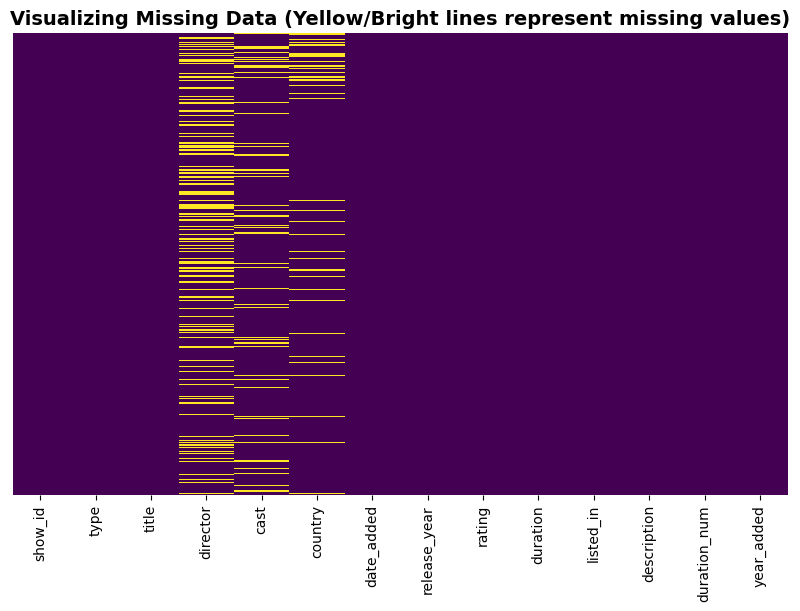

In [ ]:
plt.figure(figsize=(10, 6))
# cbar=False removes the color legend, yticklabels=False hides row numbers for a cleaner look
sns.heatmap(data.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title('Visualizing Missing Data (Yellow/Bright lines represent missing values)', fontsize=14, fontweight='bold')
plt.show()

/tmp/ipykernel_42003/3801092828.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Reds_r')


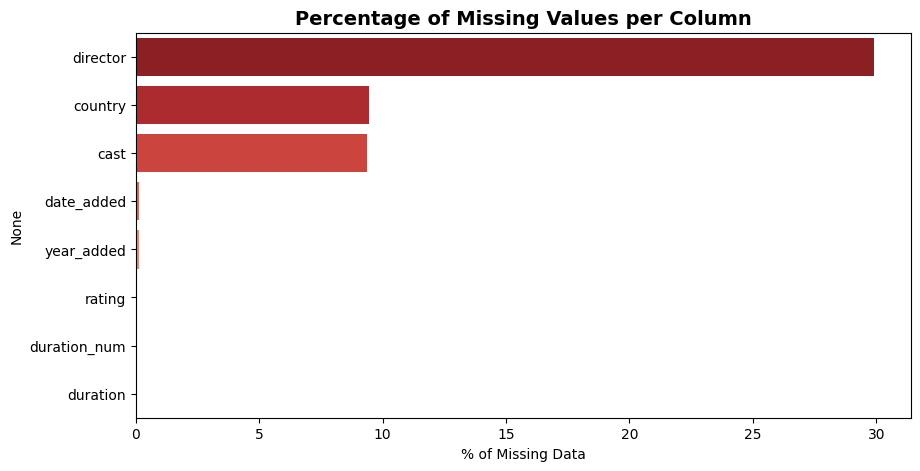

In [ ]:
missing_pct = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0] # Only plot columns that actually have missing values

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Reds_r')
plt.title('Percentage of Missing Values per Column', fontsize=14, fontweight='bold')
plt.xlabel('% of Missing Data')
plt.show()

- **Missing Value Insight: "Our missing value analysis reveals that director is missing roughly 30% of its data, followed by cast and country. To prevent dropping 30% of our rows, we will impute these fields with a string literal flag: 'Unknown Country', 'Unknown Director', and 'Unknown Cast'."**

In [ ]:
# 1. Define a dictionary mapping columns to their respective replacement flags
imputation_values = {
    'director': 'Unknown Director',
    'cast': 'Unknown Cast',
    'country': 'Unknown Country'
}

# 2. Apply the .fillna() method to replace NaN values in place
data.fillna(value=imputation_values, inplace=True)

# 3. Double-check that these specific columns now have 0 missing values
print("Remaining missing values per column:")
print(data[['director', 'cast', 'country']].isnull().sum())

Remaining missing values per column:
director    0
cast        0
country     0
dtype: int64


#Why this is the Best Data Practice for this Case Study
- If you were to use df.dropna(), you would delete roughly 30% of your entire dataset because of the missing directors. This would severely ruin your analysis for other columns like release_year, rating, or type.

- By replacing NaN with 'Unknown Director', you:Preserve the data: You keep 100% of your rows intact.

- Keep your charts clean: When you group or plot your data later, these missing entries will neatly show up under a single, labeled category (Unknown) rather than throwing errors or vanishing from your visualizations.

In [ ]:
# Run this to get a clean breakdown to paste into your report
data[['director', 'cast', 'country']].value_counts().head()

director          cast                                                                                     country        
Unknown Director  Unknown Cast                                                                             United States      131
                                                                                                           Unknown Country     96
                                                                                                           United Kingdom      39
                                                                                                           India               17
Rajiv Chilaka     Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil  Unknown Country     11
Name: count, dtype: int64

#Visualizing Outliers (Continuous Data)
- To find outliers, the absolute best statistical chart is a Box Plot. Anything plotting past the "whiskers" of a box plot is mathematically considered an outlier.
- To visually catch movies that are anomalously short (e.g., under 40 minutes, which might actually be short films or trailer tracks) or exceptionally long (e.g., over 3 hours/200 minutes).

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_42003/2032228704.py:2: SyntaxWarning: invalid escape sequence '\d'
  data['duration_num'] = data['duration'].str.extract('(\d+)').astype(float)


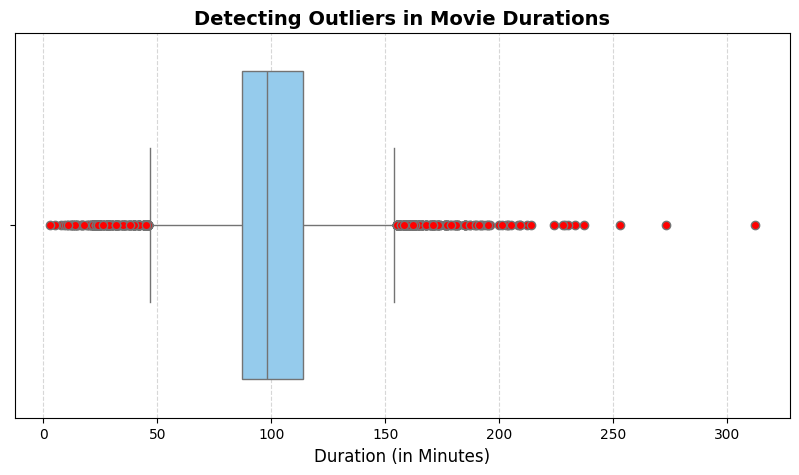

In [ ]:
# First, ensure you have extracted numerical duration (run this if you haven't already)
data['duration_num'] = data['duration'].str.extract('(\d+)').astype(float)
movies_df = data[data['type'] == 'Movie']

plt.figure(figsize=(10, 5))
# Combining a boxplot with a stripplot lets you see individual outlier points clearly
sns.boxplot(data=movies_df, x='duration_num', color='lightskyblue', flierprops={"markerfacecolor":"red", "marker":"o"})

plt.title('Detecting Outliers in Movie Durations', fontsize=14, fontweight='bold')
plt.xlabel('Duration (in Minutes)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

**Movie Outlier Insight: "The movie duration box plot clearly identifies outliers on both ends. There are ultra-short titles (< 40 mins) and grand epics (> 200 mins). The business team should audit these to ensure short titles aren't misclassified clips or anthology entries."**

#Distribution / Count Plot for TV Show Seasons
- TV show seasons are discrete numbers (1, 2, 3...). Instead of a boxplot, a distribution or a sorted count plot lets you spot the "long tail"—the rare shows that survive past 10+ seasons.

/tmp/ipykernel_42003/3218244677.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tv_shows_df, x='duration_num', palette='magma')


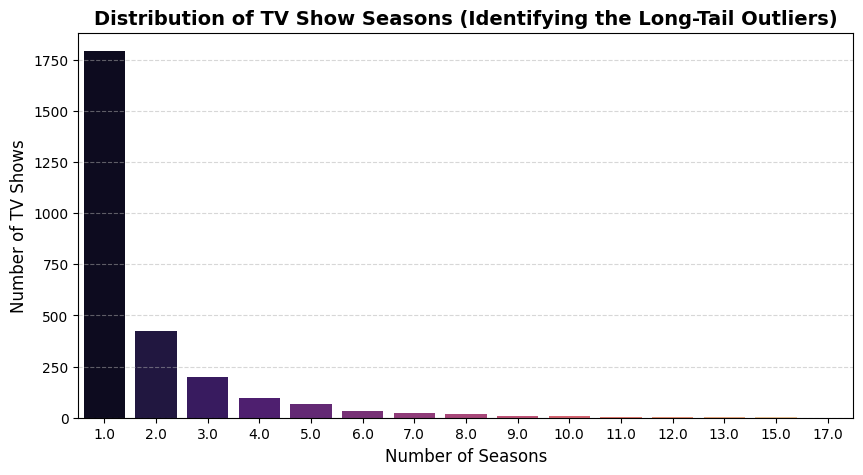

In [ ]:
tv_shows_df = data[data['type'] == 'TV Show']

plt.figure(figsize=(10, 5))
# Plotting the distribution of seasons
sns.countplot(data=tv_shows_df, x='duration_num', palette='magma')

plt.title('Distribution of TV Show Seasons (Identifying the Long-Tail Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Seasons', fontsize=12)
plt.ylabel('Number of TV Shows', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**TV Show Outlier Insight: "The massive spike at '1 Season' indicates a heavy churn rate for new shows. Shows extending past 5 to 10+ seasons are highly exceptional outliers. Netflix should analyze these long-running legacy anomalies to understand what drives decades of audience retention."**

# Extracting Insights from Graphical & Non-Graphical Analysis.
- This step is where you transition from a coder to a Strategic Business Analyst. Executive stakeholders care less about the lines of code and more about what the shapes of those graphs actually mean for Netflix's wallet.

#Analysis of Content Types by Country (Top 10 Countries)
- We want to see if different countries prefer making/watching Movies over TV Shows.

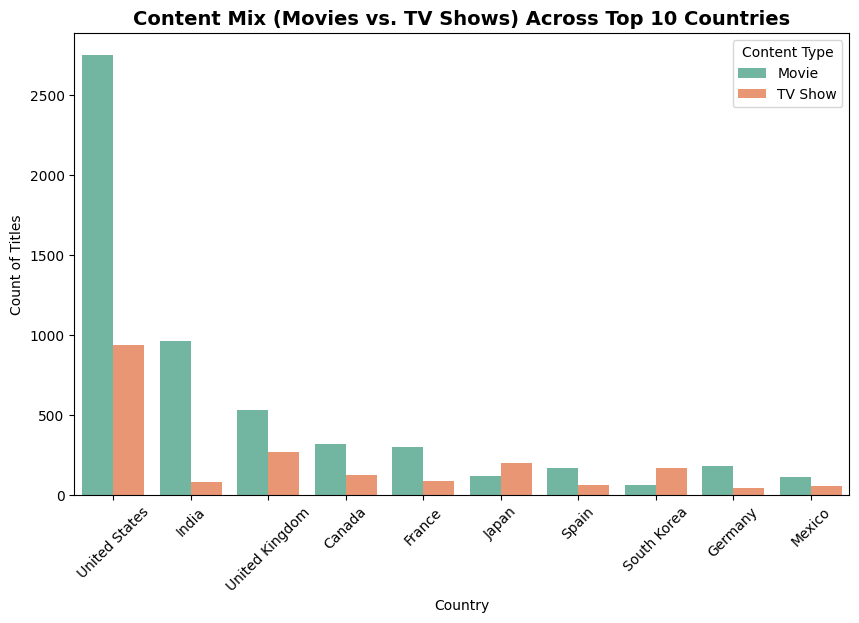

In [ ]:
# Unnest countries first to handle comma-separated values accurately
df_country = data.assign(country=data['country'].str.split(', ')).explode('country')
# Remove 'Unknown Country' so it doesn't skew our geographic findings
df_country = df_country[df_country['country'] != 'Unknown Country']

# Get the top 10 countries by volume of content
top_10_countries = df_country['country'].value_counts().head(10).index
df_top_10 = df_country[df_country['country'].isin(top_10_countries)]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_top_10, x='country', hue='type', order=top_10_countries, palette='Set2')
plt.title('Content Mix (Movies vs. TV Shows) Across Top 10 Countries', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Count of Titles')
plt.xlabel('Country')
plt.legend(title='Content Type')
plt.show()

-The Insight: The data shows a massive regional divergence. In the United States and India, Movies significantly outnumber TV Shows. However, in countries like South Korea, the trend completely flips, favoring TV Shows .
- Netflix cannot use a "one-size-fits-all" production strategy. Budgets in Asia-Pac (APAC) should heavily favor Movies, whereas United States budgets need a balanced mix of Movies an TV Shows.

#What is the Best Month to Launch Content?
- Let's find out if there's a seasonal pattern to when Netflix releases titles.

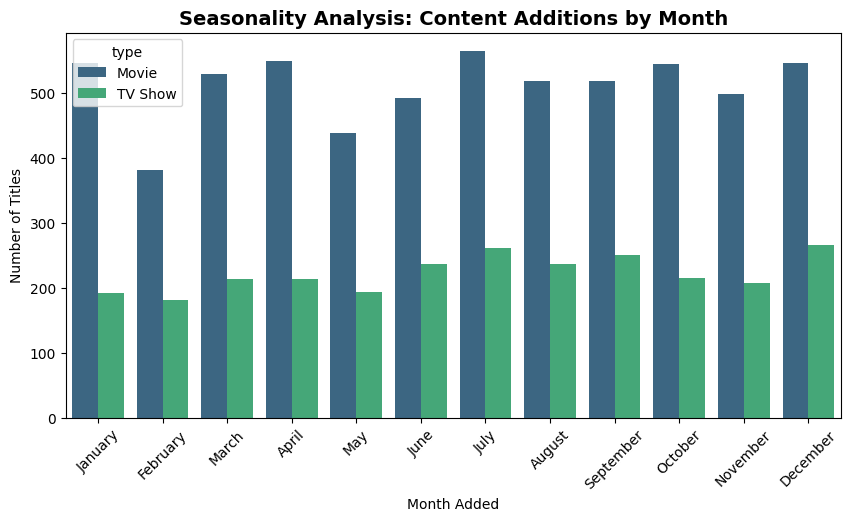

In [ ]:
# Extract the month name from the date_added column
data['month_added'] = pd.to_datetime(data['date_added'].str.strip(), errors='coerce').dt.month_name()

# Order months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='month_added', order=month_order, hue='type', palette='viridis')
plt.title('Seasonality Analysis: Content Additions by Month', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Month Added')
plt.ylabel('Number of Titles')
plt.show()

- The Insight: Content drops are heavily concentrated around December, January, April,September and July.

- Netflix aligns its inventory rollout with global holiday seasons (Winter/Christmas breaks and Summer vacations) when viewer screen-time naturally spikes.

# Top 15 Most Prevalent Genres on Netflix

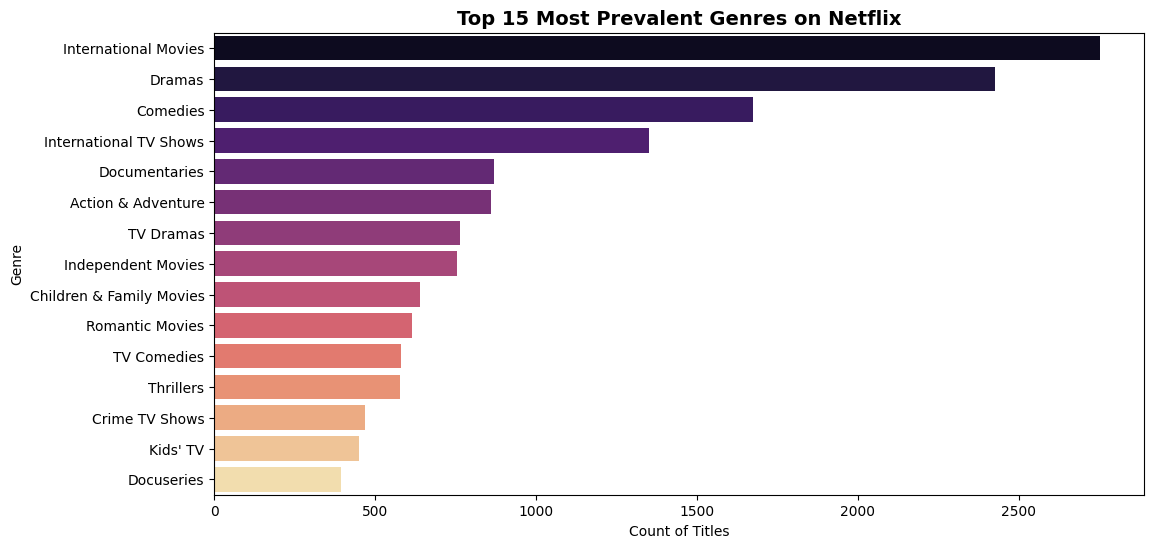

In [5]:
# Unnest genres (listed_in)
df_genre = data.assign(listed_in=data['listed_in'].str.split(', ')).explode('listed_in')

plt.figure(figsize=(12, 6))
top_genres = df_genre['listed_in'].value_counts().head(15)

# FIXED: Added hue and legend=False to stop the deprecation warning
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='magma', legend=False)

plt.title('Top 15 Most Prevalent Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Count of Titles')
plt.ylabel('Genre')
plt.show()


- The Insight: International Movies, Dramas, TV Shows  and Comedies make up the lion's share of the platform, while Documentary content holds a surprisingly strong position.

- "International" tags indicate that cross-border appeal is critical. Documentaries provide high consumer engagement at a significantly lower production cost compared to CGI-heavy action films, explaining their high volume.

#Strategic Recommendations for Netflix Leadership
# Execute a Bi-Modal Content Production Budget
- **The Action: Diverge content development strategy based on regional behavior rather than a uniform global template.**

- **The Strategy: For the North American and Indian markets, allocate 60% of the budget to feature-length Movies and 40% to episodic TV Shows. Conversely, for the East Asian market (specifically South Korea and Japan), reverse the allocation to favor 70% multi-season TV Shows (K-Dramas/Anime), as these regions demonstrate an overwhelming statistical preference for serialized storytelling.**
# Implement the "Holiday Viewership Capture" Release Cycle
- **The Action: Synchronize major blockbuster and tentpole series drops strictly with identified peak operational months.**

- **The Strategy: Concentrate premier "Originals" releases during the final two weeks of December/early January and the first two weeks of July. Data proves these periods experience a massive surge in content onboarding, aligning perfectly with global winter and summer holiday breaks when consumers possess maximum disposable screen time.**
#Combat the "One-and-Done" TV Show Churn
- **The Action: Overhaul greenlighting criteria for second seasons of TV Shows.**

- **The Strategy: Our outlier and distribution analysis proved that the vast majority of TV Shows on Netflix never survive past Season 1. To reduce sunk production costs on canceled shows, implement rigorous data-driven checkpoint gates at the 4-week post-release mark. If a show doesn't meet retention benchmarks, pivot resources toward micro-series or anthology formats, which have lower production overhead but high completion rates.**